In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [10]:
avg_gap = pd.read_csv("avg.purchace_gap.csv")

In [11]:
df1 = pd.read_csv("FINAL_PBL_DATASET_13.csv" )

In [12]:
final_df = pd.merge(df1,avg_gap , on = "CUSTOMER_ID" , how = "inner")

<Axes: >

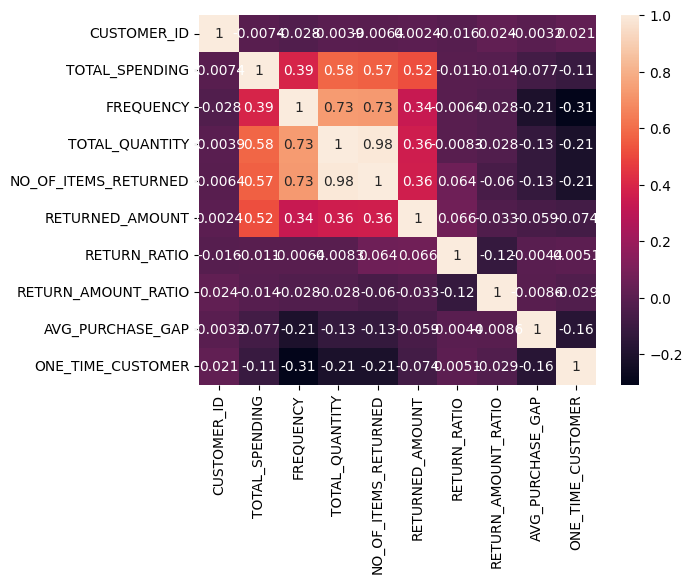

In [16]:
import seaborn as sns

sns.heatmap(final_df.corr(numeric_only = True),annot = True)

In [17]:
df1["AVG_ORDER_VALUE"] = df1["TOTAL_SPENDING"]/ df1['TOTAL_QUANTITY']

In [18]:
df1['PURCHASE_INTENSITY'] = df1['TOTAL_QUANTITY'] / df1['FREQUENCY']

In [19]:
df = df1[["CUSTOMER_ID","TOTAL_SPENDING","FREQUENCY","RETURN_RATIO",'PURCHASE_INTENSITY',"AVG_ORDER_VALUE"]]

In [20]:
final_df = pd.merge(df,avg_gap , on = "CUSTOMER_ID" , how = "inner")

In [21]:
final_df['ONE_TIME_CUSTOMER'] = (final_df['FREQUENCY'] == 1).astype(int)

In [22]:
# calculate median excluding zero values
median_gap = final_df.loc[
    final_df['AVG_PURCHASE_GAP'] > 0,
    'AVG_PURCHASE_GAP'
].median()

# replace gap for problematic cases
final_df.loc[
    (final_df['FREQUENCY'] == 1) | (final_df['AVG_PURCHASE_GAP'] == 0),
    'AVG_PURCHASE_GAP'
] = median_gap

In [23]:
final_df

,CUSTOMER_ID,TOTAL_SPENDING,FREQUENCY,RETURN_RATIO,PURCHASE_INTENSITY,AVG_ORDER_VALUE,AVG_PURCHASE_GAP,ONE_TIME_CUSTOMER
0,12346.0,270.40,1,0.500000,6.000000,45.066667,45.000000,1
1,12747.0,59992.40,11,0.071730,21.545455,253.132489,36.300000,0
2,12748.0,1839408.35,216,0.068624,50.462963,168.753060,1.382488,0
3,12749.0,169590.85,7,0.061144,72.428571,334.498718,29.428571,0
4,12820.0,13109.20,4,0.093458,26.750000,122.515888,107.333333,0
...,...,...,...,...,...,...,...,...
3936,18280.0,7361.25,1,0.000000,25.000000,294.450000,45.000000,1
3937,18281.0,2176.20,1,0.000000,25.000000,87.048000,45.000000,1
3938,18282.0,3532.10,3,0.076923,8.666667,135.850000,59.000000,0
3939,18283.0,163941.05,15,0.073990,117.133333,93.307371,21.800000,0


In [49]:
final_df.to_csv("finally.csv", index = False)

In [24]:
final_df["AVG_PURCHASE_GAP"].value_counts()

AVG_PURCHASE_GAP
45.000000     1314
4.000000        22
38.000000       20
31.000000       20
27.000000       19
              ... 
58.400000        1
80.666667        1
122.333333       1
66.666667        1
13.250000        1
Name: count, Length: 1242, dtype: int64

In [25]:
final_df["AVG_ORDER_VALUE"].value_counts()

AVG_ORDER_VALUE
0.000000      8
191.750000    8
321.750000    8
276.250000    8
165.750000    7
             ..
131.867021    1
232.346667    1
173.270377    1
47.357143     1
187.801689    1
Name: count, Length: 3844, dtype: int64

In [26]:
final_df["PURCHASE_INTENSITY"].value_counts()

PURCHASE_INTENSITY
5.000000     41
2.000000     40
18.000000    38
13.000000    35
19.000000    34
             ..
28.375000     1
40.058824     1
47.923077     1
22.600000     1
93.333333     1
Name: count, Length: 1415, dtype: int64

In [27]:
final_df["RETURN_RATIO"].value_counts()

RETURN_RATIO
0.000000    583
0.052632     32
0.083333     29
0.076923     29
0.055556     28
           ... 
0.097087      1
0.008130      1
0.050691      1
0.085938      1
0.125413      1
Name: count, Length: 1724, dtype: int64

In [28]:
df.isnull().sum()

CUSTOMER_ID           0
TOTAL_SPENDING        0
FREQUENCY             0
RETURN_RATIO          0
PURCHASE_INTENSITY    0
AVG_ORDER_VALUE       0
dtype: int64

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CUSTOMER_ID         3941 non-null   float64
 1   TOTAL_SPENDING      3941 non-null   float64
 2   FREQUENCY           3941 non-null   int64  
 3   RETURN_RATIO        3941 non-null   float64
 4   PURCHASE_INTENSITY  3941 non-null   float64
 5   AVG_ORDER_VALUE     3941 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 184.9 KB


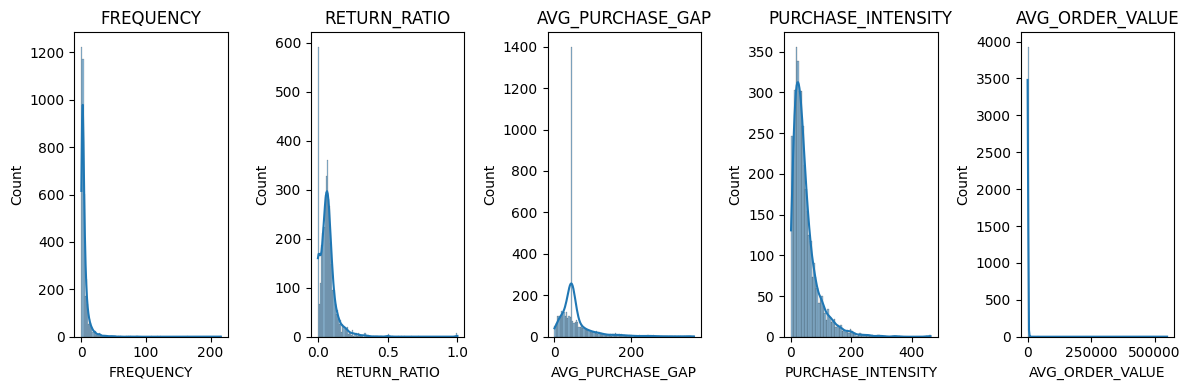

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    # 'TOTAL_SPENDING',
     'FREQUENCY',
    'RETURN_RATIO',
    'AVG_PURCHASE_GAP',
    "PURCHASE_INTENSITY",
    "AVG_ORDER_VALUE"
    
]

plt.figure(figsize=(12,4))

for i, col in enumerate(features):
    plt.subplot(1, 5, i+1)
    sns.histplot(final_df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [31]:
# import numpy as np

# cols_to_transform = [
#     'TOTAL_SPENDING',
#     'FREQUENCY',
#     'AVG_PURCHASE_GAP',
#     'PURCHASE_INTENSITY',
#     'AVG_ORDER_VALUE'
# ]

# for col in cols_to_transform:
#     final_df[col] = np.log1p(final_df[col])

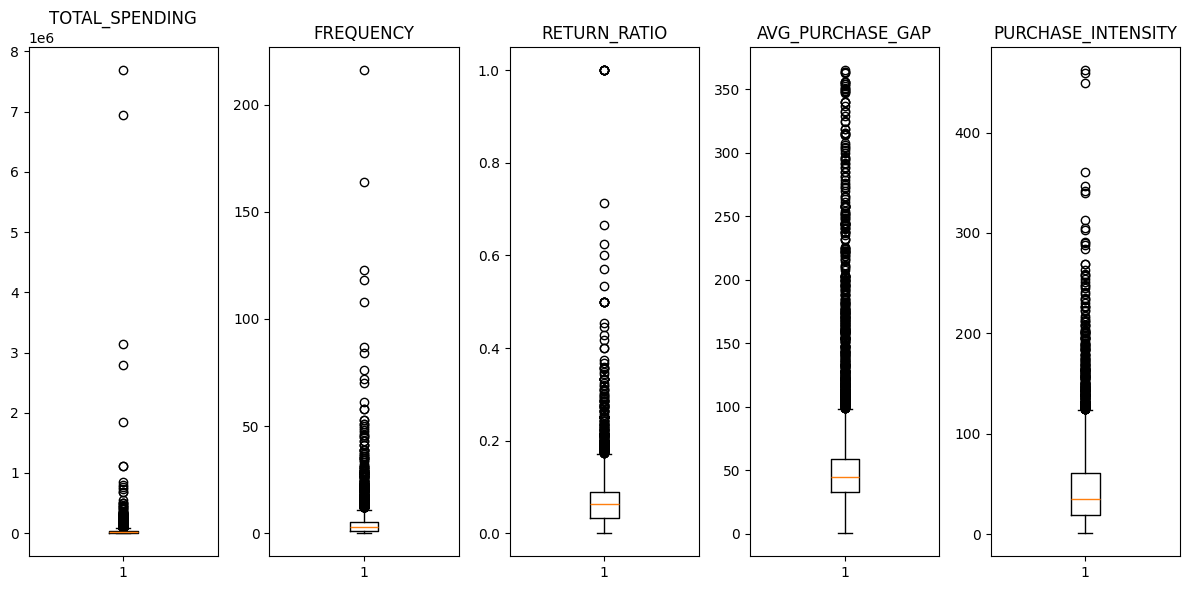

In [32]:
import matplotlib.pyplot as plt

features = [
    'TOTAL_SPENDING',
    'FREQUENCY',
    'RETURN_RATIO',
    'AVG_PURCHASE_GAP',
    "PURCHASE_INTENSITY"
]

plt.figure(figsize=(12,6))

for i, col in enumerate(features):
    plt.subplot(1, len(features), i+1)
    plt.boxplot(final_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

<Axes: >

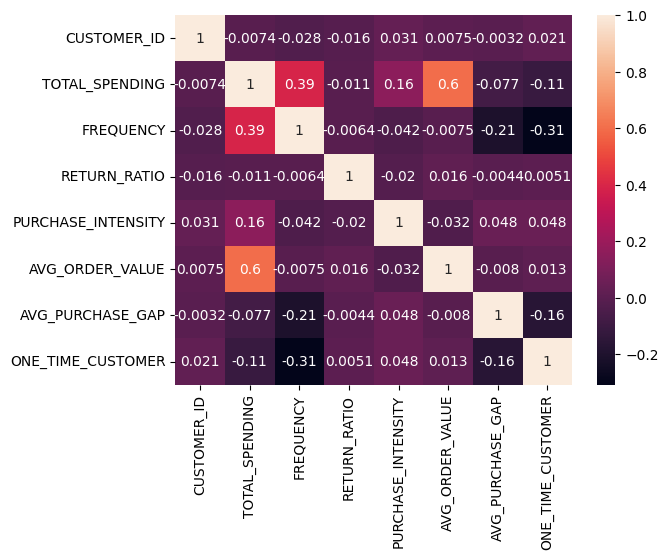

In [33]:
import seaborn as sns

sns.heatmap(final_df.corr(),annot = True)

In [34]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CUSTOMER_ID         3941 non-null   float64
 1   TOTAL_SPENDING      3941 non-null   float64
 2   FREQUENCY           3941 non-null   int64  
 3   RETURN_RATIO        3941 non-null   float64
 4   PURCHASE_INTENSITY  3941 non-null   float64
 5   AVG_ORDER_VALUE     3941 non-null   float64
 6   AVG_PURCHASE_GAP    3941 non-null   float64
 7   ONE_TIME_CUSTOMER   3941 non-null   int64  
dtypes: float64(6), int64(2)
memory usage: 246.4 KB


In [35]:
final_df.isnull().sum()

CUSTOMER_ID           0
TOTAL_SPENDING        0
FREQUENCY             0
RETURN_RATIO          0
PURCHASE_INTENSITY    0
AVG_ORDER_VALUE       0
AVG_PURCHASE_GAP      0
ONE_TIME_CUSTOMER     0
dtype: int64

In [36]:
final_df = final_df.replace([np.inf, -np.inf], 0)
final_df = final_df.fillna(0)

In [37]:
final_df

,CUSTOMER_ID,TOTAL_SPENDING,FREQUENCY,RETURN_RATIO,PURCHASE_INTENSITY,AVG_ORDER_VALUE,AVG_PURCHASE_GAP,ONE_TIME_CUSTOMER
0,12346.0,270.40,1,0.500000,6.000000,45.066667,45.000000,1
1,12747.0,59992.40,11,0.071730,21.545455,253.132489,36.300000,0
2,12748.0,1839408.35,216,0.068624,50.462963,168.753060,1.382488,0
3,12749.0,169590.85,7,0.061144,72.428571,334.498718,29.428571,0
4,12820.0,13109.20,4,0.093458,26.750000,122.515888,107.333333,0
...,...,...,...,...,...,...,...,...
3936,18280.0,7361.25,1,0.000000,25.000000,294.450000,45.000000,1
3937,18281.0,2176.20,1,0.000000,25.000000,87.048000,45.000000,1
3938,18282.0,3532.10,3,0.076923,8.666667,135.850000,59.000000,0
3939,18283.0,163941.05,15,0.073990,117.133333,93.307371,21.800000,0


In [38]:
# features = [
#     'TOTAL_SPENDING',
#     'FREQUENCY',
#     'AVG_PURCHASE_GAP',
#     "AVG_ORDER_VALUE",
#     'RETURN_RATIO',
# ]

features = ['TOTAL_SPENDING', 'FREQUENCY', 'RETURN_RATIO', 'AVG_PURCHASE_GAP', 'AVG_ORDER_VALUE',"ONE_TIME_CUSTOMER"]

In [39]:
Q1 = final_df['AVG_PURCHASE_GAP'].quantile(0.25)
Q3 = final_df['AVG_PURCHASE_GAP'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = final_df[
    (final_df['AVG_PURCHASE_GAP'] >= lower) &
    (final_df['AVG_PURCHASE_GAP'] <= upper)]



Q1 = final_df['TOTAL_SPENDING'].quantile(0.25)
Q3 = final_df['TOTAL_SPENDING'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = final_df[
    (final_df['TOTAL_SPENDING'] >= lower) &
    (final_df['TOTAL_SPENDING'] <= upper)
]

In [40]:
X = df_clean[features]

In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

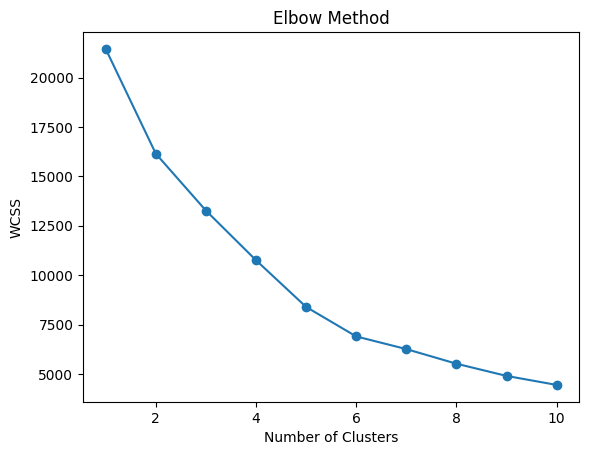

In [43]:
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [44]:
k = 3  # change based on elbow/silhouette

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_scaled)


C:\Users\tanis\AppData\Local\Temp\ipykernel_19048\993235786.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Cluster'] = kmeans.fit_predict(X_scaled)


In [45]:
score = silhouette_score(X_scaled, df_clean['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.36969395906657077


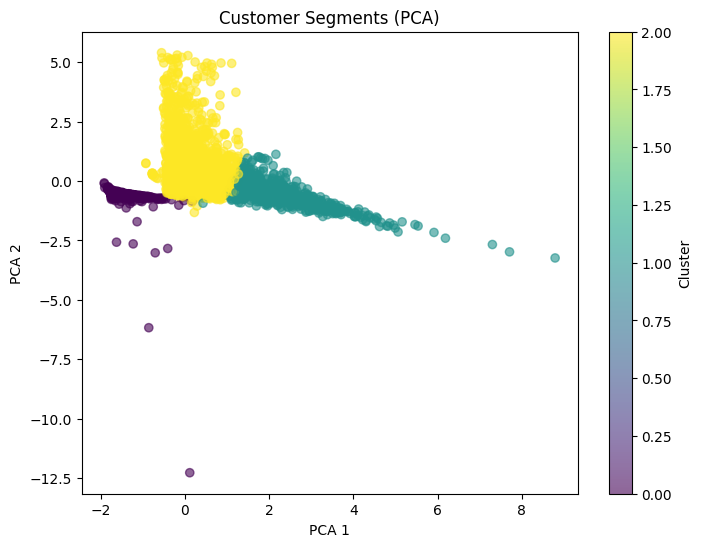

In [46]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_clean['Cluster'], cmap='viridis', alpha=0.6)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments (PCA)")

plt.colorbar(label='Cluster')
plt.show()

In [47]:
cluster_summary = df_clean.groupby('Cluster')[features].mean()

print("\nCluster Summary:\n")
print(cluster_summary)


Cluster Summary:

         TOTAL_SPENDING  FREQUENCY  RETURN_RATIO  AVG_PURCHASE_GAP  \
Cluster                                                              
0           8695.630041   1.000000      0.071206         45.000000   
1          56644.324885   8.763441      0.070841         39.212260   
2          18490.773792   3.224680      0.071328         80.348014   

         AVG_ORDER_VALUE  ONE_TIME_CUSTOMER  
Cluster                                      
0             271.828132           1.000000  
1             198.206739           0.001536  
2             188.114024           0.000000  
